# exp-gs-002-05 — H-AS + exact 4개 + stable hotspot top-3

04 best `H-AS + exact 4개`에 fold-train에서만 선정한 stable exact hotspot 최대 3개를 추가한다. 최소 발생 10회, 단일 암종 집중도 60% 이상, 기존 exact 4개 제외 규칙을 고정한다. Logistic `C=0.07`, `max_iter=2000`, 5-fold, seeds `42/2024/777`, leakage/NaN 계약을 유지한다.

In [1]:
from pathlib import Path
import subprocess, sys
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm
pd.set_option('display.max_columns', None)

def find_eda_dir():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'exp-gs-002-memory-safe.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002' / 'common' / 'exp-gs-002-memory-safe.py'
        if direct.exists(): return path
        if project.exists(): return project.parent.parent
    raise FileNotFoundError('프로젝트 루트 또는 eda_pre_002에서 실행하세요.')

EDA_DIR = find_eda_dir(); ROOT = EDA_DIR.parents[3]
RUNNER = EDA_DIR / 'common' / 'exp-gs-002-memory-safe.py'; RESULT_DIR = EDA_DIR / 'result'
RUN_ID = 'exp-gs-002-05'; MODEL = 'logistic'; SEEDS = (42, 2024, 777)
BASELINE = 'H-AS-LR-exact'; CANDIDATE = 'H-AS-LR-exact-hotspot-top3'
assert RUNNER.exists() and RESULT_DIR.exists()
{'baseline': BASELINE, 'candidate': CANDIDATE, 'seeds': SEEDS, 'selection': 'fold-train only / support>=10 / concentration>=0.60 / top-3'}

/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'baseline': 'H-AS-LR-exact',
 'candidate': 'H-AS-LR-exact-hotspot-top3',
 'seeds': (42, 2024, 777),
 'selection': 'fold-train only / support>=10 / concentration>=0.60 / top-3'}

## 실행
기본값은 `False`다. True로 바꾸면 tqdm으로 3-seed 진행을 확인할 수 있다.

In [2]:
RUN_EXPERIMENT = True
if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc=f'{RUN_ID} | 3-seed', unit='seed'):
        command = [sys.executable, str(RUNNER), '--run-id', RUN_ID, '--candidate', CANDIDATE, '--model', MODEL, '--seed', str(seed)]
        completed = subprocess.run(command, cwd=ROOT, check=False)
        if completed.returncode != 0: raise RuntimeError(f'seed={seed} 실행 실패: {completed.returncode}')
else:
    print('미실행 상태입니다. RUN_EXPERIMENT = True로 변경하세요.')

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 386.57it/s]
H-AS-LR-exact-hotspot-top3 | logistic | seed 42: 100%|██████████| 5/5 [04:49<00:00, 57.91s/it]


{
  "experiment_id": "H-AS-LR-exact-hotspot-top3",
  "model": "logistic",
  "seed": 42,
  "oof_macro_f1": 0.42945030010354307,
  "oof_accuracy": 0.4188034188034188,
  "fold_macro_f1_mean": 0.42849975483863806,
  "fold_macro_f1_std": 0.012458477606646926,
  "feature_count_mean": 8220.2,
  "runtime_seconds": 289.6380444999959,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 397.54it/s]
H-AS-LR-exact-hotspot-top3 | logistic | seed 2024: 100%|██████████| 5/5 [04:45<00:00, 57.13s/it]


{
  "experiment_id": "H-AS-LR-exact-hotspot-top3",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.43503017601240607,
  "oof_accuracy": 0.4221899693597807,
  "fold_macro_f1_mean": 0.4351590625022766,
  "fold_macro_f1_std": 0.008393230446532058,
  "feature_count_mean": 8220.0,
  "runtime_seconds": 285.77341783299926,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 400.83it/s]
H-AS-LR-exact-hotspot-top3 | logistic | seed 777: 100%|██████████| 5/5 [04:44<00:00, 56.92s/it]


{
  "experiment_id": "H-AS-LR-exact-hotspot-top3",
  "model": "logistic",
  "seed": 777,
  "oof_macro_f1": 0.43315007185544285,
  "oof_accuracy": 0.42348008385744235,
  "fold_macro_f1_mean": 0.43238290827124015,
  "fold_macro_f1_std": 0.0116881850295556,
  "feature_count_mean": 8215.4,
  "runtime_seconds": 284.68341879200307,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


exp-gs-002-05 | 3-seed: 100%|██████████| 3/3 [15:36<00:00, 312.20s/seed]


## 3-seed 결과
04 exact 4개 기준과 직접 비교한다. 모든 seed에서 `leakage_check=True`, `nan_as_mutation_count=0`이어야 한다.

,experiment_id,seed_count,macro_f1_mean,macro_f1_std,feature_count_mean,convergence_warning_count,delta_vs_exact4
0,H-AS-LR-exact,3,0.433479,0.002436,8215.533333,15,0.000000
1,H-AS-LR-exact-hotspot-top3,3,0.432544,0.002839,8218.533333,15,-0.000935


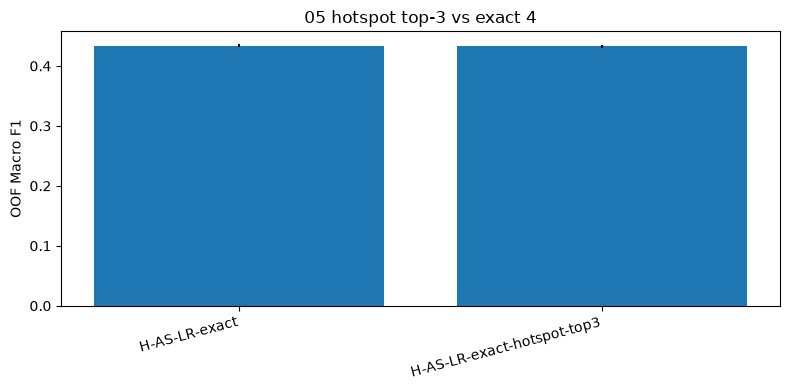

In [3]:
def path(run_id, candidate, seed): return RESULT_DIR / f'{run_id}_{candidate}_{MODEL}_seed{seed}_oof.csv'
candidate_paths = [path(RUN_ID, CANDIDATE, seed) for seed in SEEDS]
baseline_paths = [path('exp-gs-002-04', BASELINE, seed) for seed in SEEDS]
missing = [item for item in candidate_paths + baseline_paths if not item.exists()]
if missing:
    print('필요한 결과 파일이 없습니다:'); [print(' -', item.name) for item in missing]
else:
    runs = pd.concat([pd.read_csv(item) for item in candidate_paths + baseline_paths], ignore_index=True)
    assert runs['leakage_check'].all() and (runs['nan_as_mutation_count'] == 0).all()
    summary = runs.groupby('experiment_id', as_index=False).agg(seed_count=('seed','nunique'), macro_f1_mean=('oof_macro_f1','mean'), macro_f1_std=('oof_macro_f1','std'), feature_count_mean=('feature_count_mean','mean'), convergence_warning_count=('convergence_warning_count','sum'))
    base = summary.loc[summary.experiment_id.eq(BASELINE), 'macro_f1_mean'].iloc[0]
    summary['delta_vs_exact4'] = summary['macro_f1_mean'] - base
    summary.to_csv(RESULT_DIR / f'{RUN_ID}_3seed_summary.csv', index=False)
    display(summary.sort_values('macro_f1_mean', ascending=False))
    plt.figure(figsize=(8,4)); plt.bar(summary.experiment_id, summary.macro_f1_mean, yerr=summary.macro_f1_std); plt.xticks(rotation=15, ha='right'); plt.ylabel('OOF Macro F1'); plt.title('05 hotspot top-3 vs exact 4'); plt.tight_layout(); plt.show()